In [1]:
# ============================================================
# ETAPA 4 — BLOCO 1: Setup, dados e carregar ResNet50 treinada
# ============================================================
!pip install medmnist grad-cam -q

import numpy as np, torch, torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset
from medmnist import PathMNIST
import os, matplotlib.pyplot as plt

np.random.seed(42); torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

MEAN=[0.485,0.456,0.406]; STD=[0.229,0.224,0.225]
ARQ = "/root/.medmnist/pathmnist_224.npz"

# Garante download dos dados
if not os.path.exists(ARQ):
    print("Baixando dados...")
    _ = PathMNIST(split="train", size=224, download=True)

dados = np.load(ARQ, mmap_mode="r")
X_val_mm = dados["val_images"]; y_val_mm = dados["val_labels"]

class PathDatasetMM(Dataset):
    def __init__(self, X, y, indices=None):
        self.X=X; self.y=y
        self.indices = indices if indices is not None else range(len(X))
        self.tf = transforms.Compose([transforms.ToTensor(),
                                      transforms.Normalize(mean=MEAN, std=STD)])
    def __len__(self): return len(self.indices)
    def __getitem__(self, i):
        j = self.indices[i]
        img = self.tf(np.array(self.X[j]))
        label = int(np.array(self.y[j]).flatten()[0])
        return img, label

val_ds = PathDatasetMM(X_val_mm, y_val_mm)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

# --- Recriar a ResNet50 e carregar os pesos treinados ---
PATH_PTH = "/kaggle/input/datasets/rawennedasilvaleite/resnet50-pathmnist/resnet50_ft.pth"

modelo = models.resnet50(weights=None)   # estrutura vazia (sem pesos do ImageNet)
modelo.fc = nn.Linear(modelo.fc.in_features, 9)   # mesma troca da Etapa 3 (9 classes)
modelo.load_state_dict(torch.load(PATH_PTH, map_location=device))
modelo = modelo.to(device)
modelo.eval()
print("Modelo ResNet50 carregado com pesos treinados.")

# --- Testar: acurácia num pedaço da validação (deve dar ~99%) ---
acertos, total = 0, 0
with torch.no_grad():
    for i, (imgs, labels) in enumerate(val_loader):
        imgs = imgs.to(device); labels = labels.long().to(device)
        preds = torch.argmax(modelo(imgs), dim=1)
        acertos += (preds == labels).sum().item(); total += labels.size(0)
        if i >= 20: break   # só 20 batches pra testar rápido
print(f"Acurácia em ~{total} imagens de validação: {acertos/total:.4f}")
print("(Esperado: ~0.99, confirmando que é o modelo treinado certo)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.5 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.3 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml

100%|██████████| 12.6G/12.6G [14:39<00:00, 14.4MB/s]  


Modelo ResNet50 carregado com pesos treinados.
Acurácia em ~1344 imagens de validação: 0.9881
(Esperado: ~0.99, confirmando que é o modelo treinado certo)


Shape dos feature maps: torch.Size([64, 112, 112]) (64 filtros, 112x112 cada)
Figura salva como 'feature_maps.png'


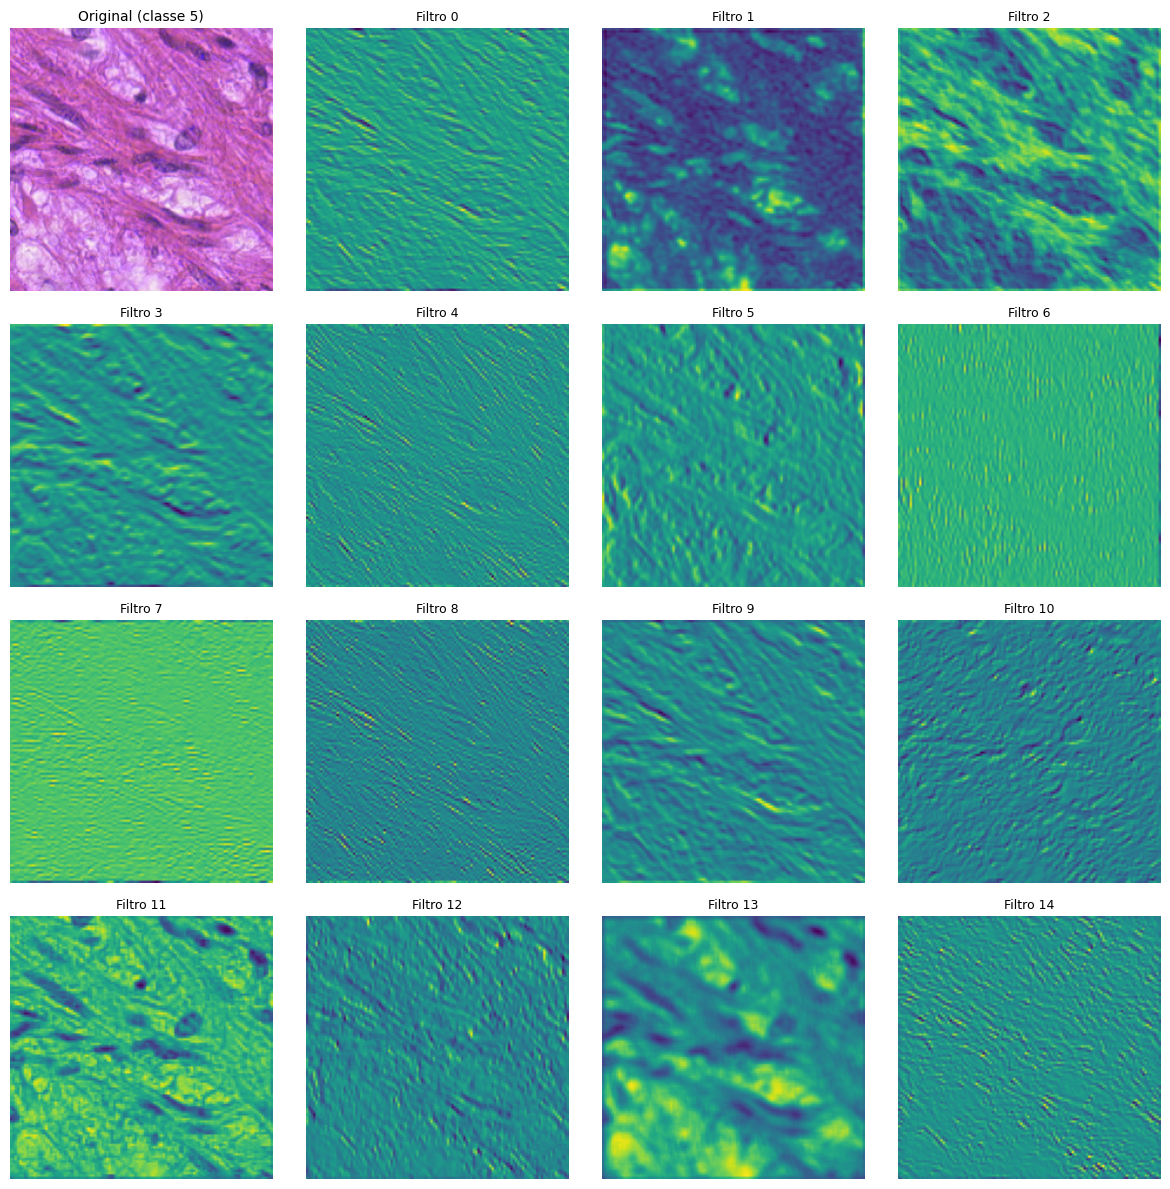

In [3]:
# ============================================================
# ETAPA 4 — BLOCO 2: Feature Maps (mapas de ativação)
# ============================================================

# Pegar uma imagem de validação
img_tensor, label = val_ds[0]
img_batch = img_tensor.unsqueeze(0).to(device)   # adiciona dimensão de batch [1,3,224,224]

# --- Capturar a saída da primeira camada convolucional ---
# Na ResNet, a primeira conv é 'modelo.conv1'
ativacoes = {}
def hook(module, input, output):
    ativacoes["conv1"] = output.detach()

h = modelo.conv1.register_forward_hook(hook)
with torch.no_grad():
    _ = modelo(img_batch)
h.remove()

feature_maps = ativacoes["conv1"][0]   # [64, 112, 112] - 64 filtros
print("Shape dos feature maps:", feature_maps.shape, "(64 filtros, 112x112 cada)")

# --- Plotar a imagem original + 15 feature maps ---
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

# Primeira posição: imagem original (desnormalizada para visualizar)
img_vis = img_tensor.cpu().numpy().transpose(1, 2, 0)
img_vis = img_vis * np.array(STD) + np.array(MEAN)   # desfaz a normalização
img_vis = np.clip(img_vis, 0, 1)
axes[0, 0].imshow(img_vis)
axes[0, 0].set_title(f"Original (classe {label})", fontsize=10)
axes[0, 0].axis("off")

# Outras 15 posições: feature maps de 15 filtros diferentes
for idx in range(1, 16):
    linha, col = idx // 4, idx % 4
    fmap = feature_maps[idx-1].cpu().numpy()
    axes[linha, col].imshow(fmap, cmap="viridis")
    axes[linha, col].set_title(f"Filtro {idx-1}", fontsize=9)
    axes[linha, col].axis("off")

plt.tight_layout()
plt.savefig("feature_maps.png", dpi=120, bbox_inches="tight")
print("Figura salva como 'feature_maps.png'")
plt.show()

In [2]:
# ============================================================
# ETAPA 4 — BLOCO 3: Coletar previsões para selecionar casos
# ============================================================
import torch.nn.functional as F

# Vamos rodar o modelo em N imagens de validação e guardar:
# índice, classe real, classe prevista, confiança (probabilidade do softmax)
N_AMOSTRAS = 2000
registros = []

modelo.eval()
with torch.no_grad():
    for i in range(N_AMOSTRAS):
        img_t, label = val_ds[i]
        logits = modelo(img_t.unsqueeze(0).to(device))
        probs = F.softmax(logits, dim=1)
        conf, pred = torch.max(probs, dim=1)
        registros.append({
            "idx": i,
            "real": label,
            "pred": pred.item(),
            "conf": conf.item(),
            "acertou": pred.item() == label
        })

# Separar os casos que o enunciado pede
acertos_confiantes = sorted([r for r in registros if r["acertou"]],
                            key=lambda r: -r["conf"])[:5]
erros = sorted([r for r in registros if not r["acertou"]],
               key=lambda r: -r["conf"])[:5]   # erros com ALTA confiança (mais "grosseiros")

print(f"Total analisado: {len(registros)} imagens")
print(f"Acertos: {sum(r['acertou'] for r in registros)} | Erros: {sum(not r['acertou'] for r in registros)}\n")

print("5 ACERTOS com alta confiança:")
for r in acertos_confiantes:
    print(f"  idx {r['idx']}: real={r['real']} pred={r['pred']} conf={r['conf']:.3f}")

print("\n5 ERROS com alta confiança (erros 'grosseiros'):")
for r in erros:
    print(f"  idx {r['idx']}: real={r['real']} pred={r['pred']} conf={r['conf']:.3f}")

Total analisado: 2000 imagens
Acertos: 1979 | Erros: 21

5 ACERTOS com alta confiança:
  idx 12: real=2 pred=2 conf=1.000
  idx 25: real=6 pred=6 conf=1.000
  idx 31: real=2 pred=2 conf=1.000
  idx 33: real=8 pred=8 conf=1.000
  idx 66: real=8 pred=8 conf=1.000

5 ERROS com alta confiança (erros 'grosseiros'):
  idx 22: real=4 pred=8 conf=1.000
  idx 235: real=6 pred=8 conf=0.990
  idx 308: real=5 pred=7 conf=0.969
  idx 1556: real=6 pred=8 conf=0.965
  idx 739: real=2 pred=7 conf=0.951


Gerando Grad-CAM dos acertos...


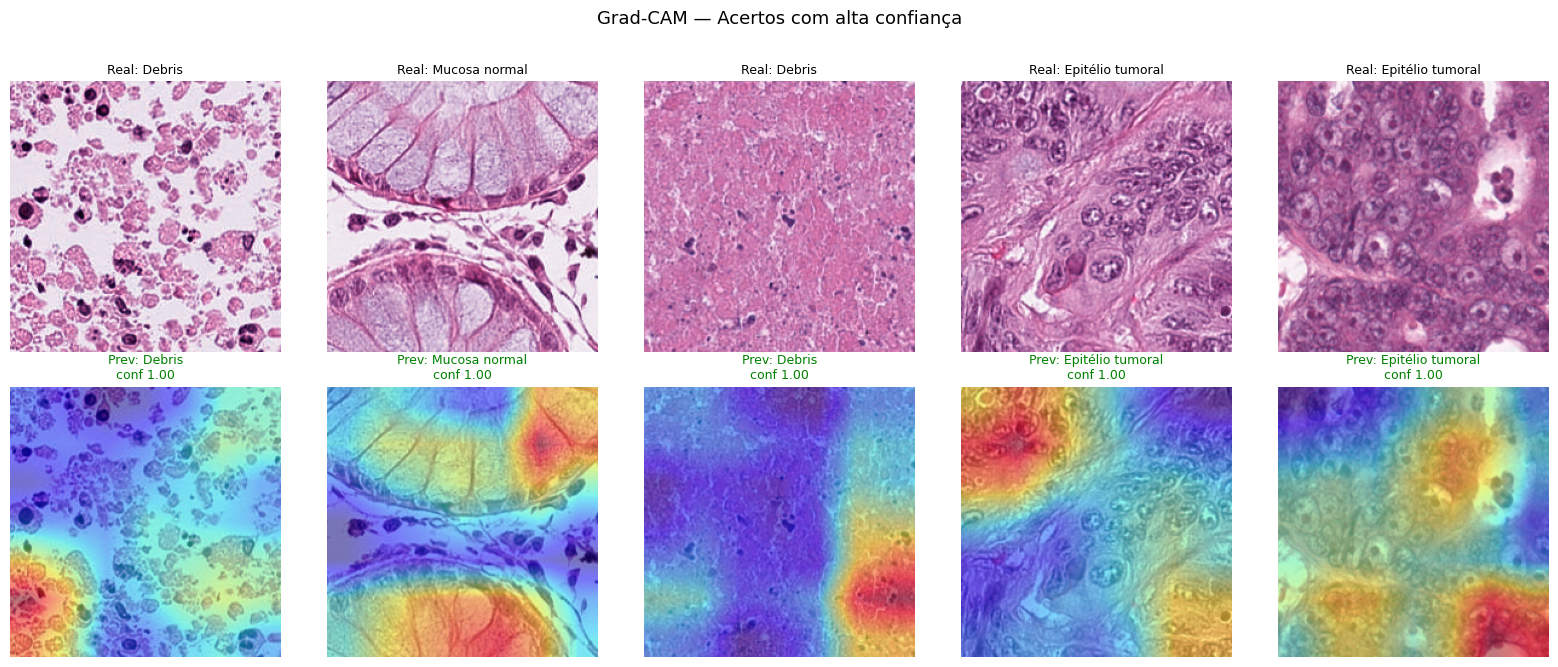

Salvo: gradcam_acertos.png

Gerando Grad-CAM dos erros...


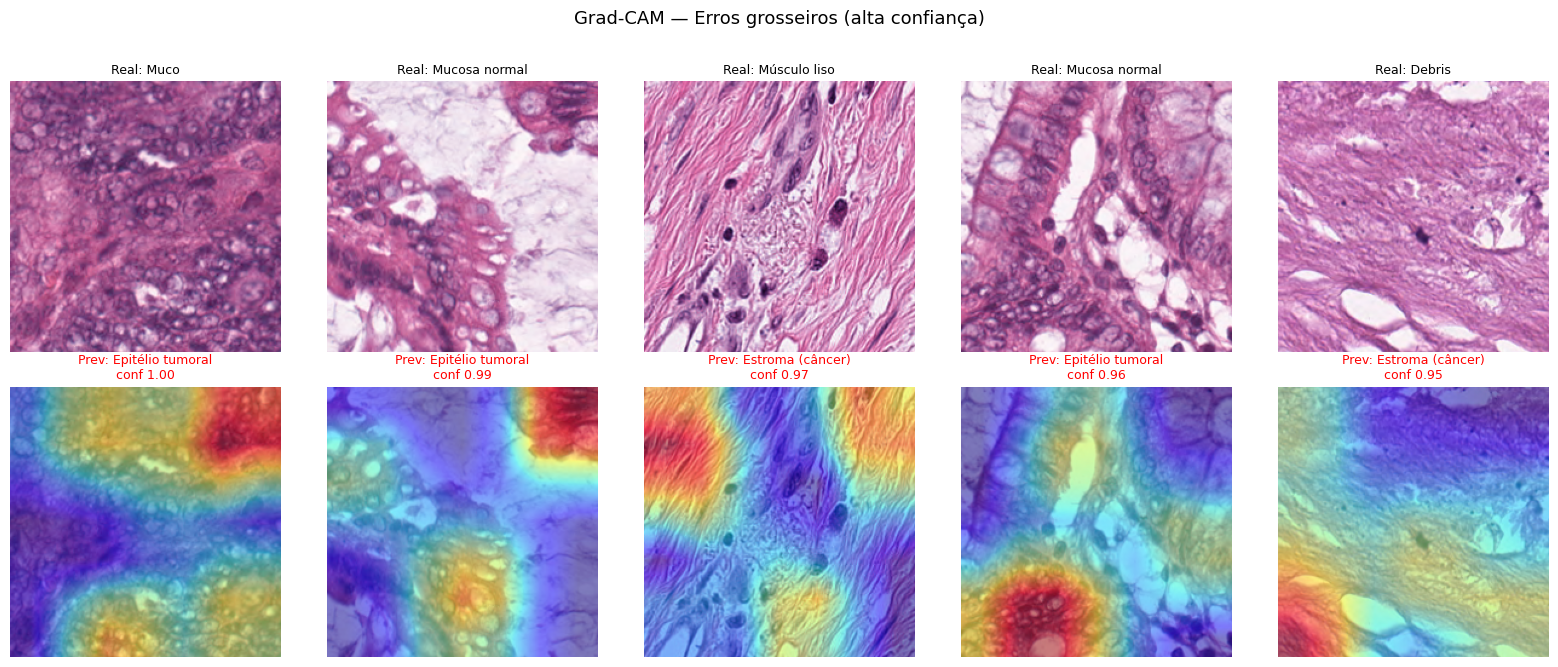

Salvo: gradcam_erros.png


In [3]:
# ============================================================
# ETAPA 4 — BLOCO 4: Grad-CAM nos casos selecionados
# ============================================================
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Nomes das 9 classes do PathMNIST (para legendas)
CLASSES = ["Tec. adiposo", "Fundo", "Debris", "Linfócitos", "Muco",
           "Músculo liso", "Mucosa normal", "Estroma (câncer)", "Epitélio tumoral"]

# A camada-alvo do Grad-CAM: última camada convolucional da ResNet (layer4)
target_layers = [modelo.layer4[-1]]
cam = GradCAM(model=modelo, target_layers=target_layers)

def desnormalizar(img_tensor):
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(STD) + np.array(MEAN)
    return np.clip(img, 0, 1)

def plotar_gradcam(casos, titulo, nome_arquivo):
    n = len(casos)
    fig, axes = plt.subplots(2, n, figsize=(3.2*n, 6.5))
    if n == 1:
        axes = axes.reshape(2, 1)
    for col, r in enumerate(casos):
        img_t, label = val_ds[r["idx"]]
        entrada = img_t.unsqueeze(0).to(device)
        # Grad-CAM para a classe PREVISTA pelo modelo
        grayscale_cam = cam(input_tensor=entrada,
                            targets=[ClassifierOutputTarget(r["pred"])])[0]
        img_vis = desnormalizar(img_t)

        # Linha de cima: imagem original
        axes[0, col].imshow(img_vis)
        axes[0, col].set_title(f"Real: {CLASSES[r['real']]}", fontsize=9)
        axes[0, col].axis("off")

        # Linha de baixo: imagem + mapa de calor sobreposto
        axes[1, col].imshow(img_vis)
        axes[1, col].imshow(grayscale_cam, cmap="jet", alpha=0.5)
        cor = "green" if r["acertou"] else "red"
        axes[1, col].set_title(f"Prev: {CLASSES[r['pred']]}\nconf {r['conf']:.2f}",
                               fontsize=9, color=cor)
        axes[1, col].axis("off")

    fig.suptitle(titulo, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Salvo: {nome_arquivo}")

# Gerar os mapas
print("Gerando Grad-CAM dos acertos...")
plotar_gradcam(acertos_confiantes, "Grad-CAM — Acertos com alta confiança", "gradcam_acertos.png")

print("\nGerando Grad-CAM dos erros...")
plotar_gradcam(erros, "Grad-CAM — Erros grosseiros (alta confiança)", "gradcam_erros.png")

Caso 'acerto por sorte' encontrado:
  idx 332 | classe Debris | conf 1.000 | 76% do calor nas bordas


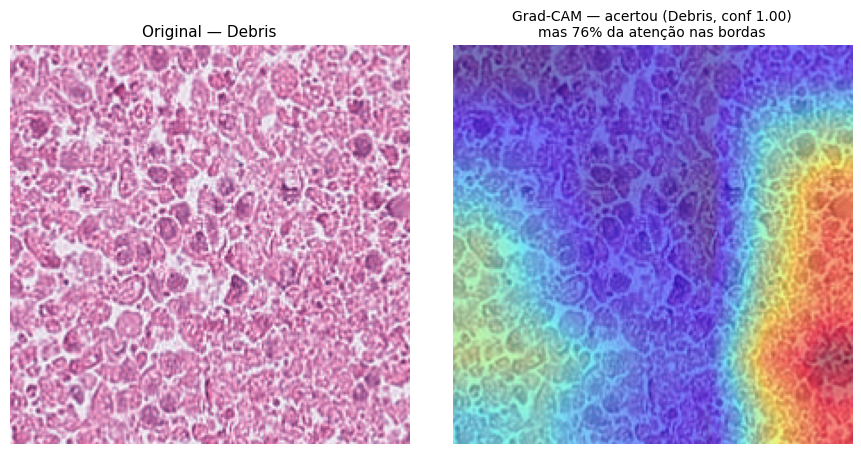

Salvo: gradcam_acerto_sorte.png


In [4]:
# ============================================================
# ETAPA 4 — BLOCO 5: Buscar e plotar "acerto por sorte"
# ============================================================

# Estratégia: entre os acertos, medir quanto do "calor" do Grad-CAM cai nas
# BORDAS da imagem (faixa externa). Calor alto nas bordas = modelo olhou pro
# fundo/artefato em vez do centro onde está o tecido = "acerto por sorte".

def fracao_calor_borda(grayscale_cam, margem=0.20):
    """Fração da ativação total que está na faixa de borda da imagem."""
    h, w = grayscale_cam.shape
    m_h, m_w = int(h*margem), int(w*margem)
    total = grayscale_cam.sum() + 1e-8
    # cria máscara: True nas bordas
    mask = np.ones_like(grayscale_cam, dtype=bool)
    mask[m_h:h-m_h, m_w:w-m_w] = False   # centro = False
    calor_borda = grayscale_cam[mask].sum()
    return calor_borda / total

# Analisar os acertos confiantes (pegamos mais alguns pra ter de onde escolher)
candidatos = sorted([r for r in registros if r["acertou"]],
                    key=lambda r: -r["conf"])[:50]  # top 50 acertos confiantes

melhor_sorte = None
maior_borda = -1
for r in candidatos:
    img_t, label = val_ds[r["idx"]]
    gcam = cam(input_tensor=img_t.unsqueeze(0).to(device),
               targets=[ClassifierOutputTarget(r["pred"])])[0]
    fb = fracao_calor_borda(gcam)
    if fb > maior_borda:
        maior_borda = fb
        melhor_sorte = {**r, "frac_borda": fb}

print(f"Caso 'acerto por sorte' encontrado:")
print(f"  idx {melhor_sorte['idx']} | classe {CLASSES[melhor_sorte['real']]} | "
      f"conf {melhor_sorte['conf']:.3f} | {melhor_sorte['frac_borda']*100:.0f}% do calor nas bordas")

# Plotar esse caso
img_t, label = val_ds[melhor_sorte["idx"]]
gcam = cam(input_tensor=img_t.unsqueeze(0).to(device),
           targets=[ClassifierOutputTarget(melhor_sorte["pred"])])[0]
img_vis = desnormalizar(img_t)

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(img_vis)
axes[0].set_title(f"Original — {CLASSES[label]}", fontsize=11)
axes[0].axis("off")
axes[1].imshow(img_vis)
axes[1].imshow(gcam, cmap="jet", alpha=0.5)
axes[1].set_title(f"Grad-CAM — acertou ({CLASSES[melhor_sorte['pred']]}, conf {melhor_sorte['conf']:.2f})\n"
                  f"mas {melhor_sorte['frac_borda']*100:.0f}% da atenção nas bordas",
                  fontsize=10)
axes[1].axis("off")
plt.tight_layout()
plt.savefig("gradcam_acerto_sorte.png", dpi=120, bbox_inches="tight")
plt.show()
print("Salvo: gradcam_acerto_sorte.png")

Gerando Integrated Gradients dos acertos...


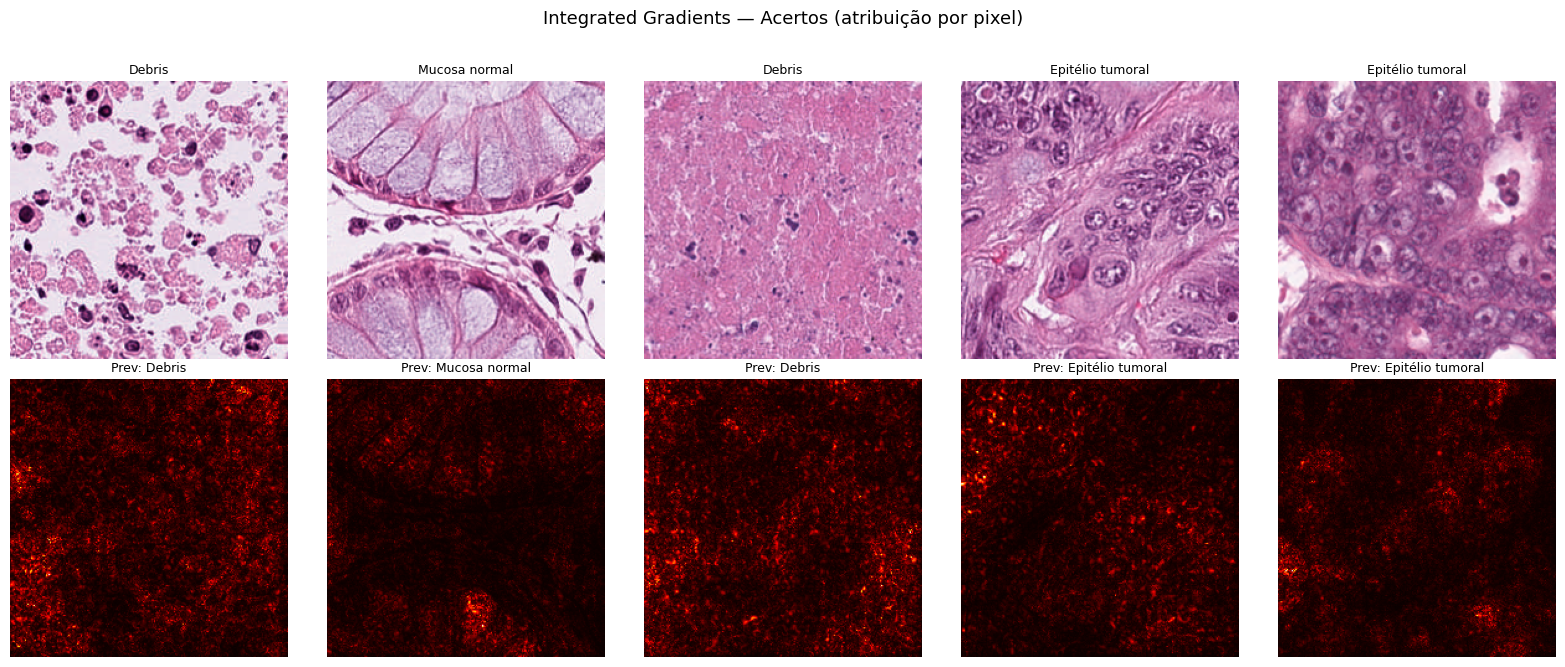

Salvo: ig_acertos.png


In [6]:
# ============================================================
# ETAPA 4 — BLOCO 6: Integrated Gradients (BÔNUS +5%) 
# ============================================================
!pip install captum -q
from captum.attr import IntegratedGradients

ig = IntegratedGradients(modelo)

def plotar_ig(idx_lista, titulo, nome_arquivo):
    n = len(idx_lista)
    fig, axes = plt.subplots(2, n, figsize=(3.2*n, 6.5))
    if n == 1:
        axes = axes.reshape(2, 1)
    for col, idx in enumerate(idx_lista):
        img_t, label = val_ds[idx]
        entrada = img_t.unsqueeze(0).to(device)
        entrada.requires_grad_()

        with torch.no_grad():
            pred = torch.argmax(modelo(entrada), dim=1).item()

        attr = ig.attribute(entrada, target=pred, baselines=entrada*0, n_steps=50)
        # .detach() desliga o tensor do grafo de gradientes antes de virar numpy
        attr_map = attr.squeeze().abs().sum(dim=0).detach().cpu().numpy()
        attr_map = attr_map / (attr_map.max() + 1e-8)

        img_vis = desnormalizar(img_t)

        axes[0, col].imshow(img_vis)
        axes[0, col].set_title(f"{CLASSES[label]}", fontsize=9)
        axes[0, col].axis("off")

        axes[1, col].imshow(attr_map, cmap="hot")
        axes[1, col].set_title(f"Prev: {CLASSES[pred]}", fontsize=9)
        axes[1, col].axis("off")

    fig.suptitle(titulo, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Salvo: {nome_arquivo}")

idx_acertos = [r["idx"] for r in acertos_confiantes]
print("Gerando Integrated Gradients dos acertos...")
plotar_ig(idx_acertos, "Integrated Gradients — Acertos (atribuição por pixel)", "ig_acertos.png")